In [1]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

# Imports from PyTorch.
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor, device, no_grad, manual_seed
from torch import max as torch_max
from torch.utils.data import DataLoader
from torchvision.datasets.utils import download_url
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from copy import deepcopy

import sys
# get the path of the current file
file = os.path.abspath('')
path = os.path.join(file, '../../src')
sys.path.append(path)
print(path)


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.optim import AnalogSGD
from aihwkit.simulator.configs.configs import (
    InferenceRPUConfig,
    TorchInferenceRPUConfig,
    # remember, the InferenceRPUConfig configuration parameter is used only for inference:
    # this means that the hardware non-idealities are considered only in the forward pass,
    # while the backward and update passes are ideal.
)
from aihwkit.simulator.configs import MappingParameter
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)


from aihwkit.simulator.parameters import (
    WeightClipParameter,
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.nn.conversion import convert_to_analog
from aihwkit.simulator.presets import StandardHWATrainingPreset
from aihwkit.simulator.parameters.enums import WeightClipType


from aihwkit.simulator.rpu_base import cuda

cur_dir = os.getcwd()
print("Current directory: ", cur_dir)
src_path = os.path.join(cur_dir, "..")
sys.path.append(src_path)
import src.plotting as pl 

# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(1)
DEVICE = torch.device("cuda:1" if USE_CUDA else "cpu")
print("Device: ", DEVICE)




# Path to store datasets
PATH_DATASET = os.path.join(cur_dir, "../data/cifar10")
print("Path to store datasets: ", PATH_DATASET)



# Training parameters
SEED = 1
N_EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 0.001
N_CLASSES = 10

/home/ecabiati/cellar/aihwkit/sandbox/cuda/../../src
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda
Device:  cuda:1
Path to store datasets:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/cifar10


## Define the model to be used for evaluation

The model used for evaluation is a 9-layer ResNet (He et al. 2015) for image classification on CIFAR-10 dataset (https://github.com/matthias-wright/cifar10-resnet/). We will load the pre-trained model, fine-tune it, using both hardware aware and quantization aware training, and finally evaluate and compare the performance of the models for different quantization levels.

In [2]:
class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def resnet9s_analog(channels, RPU_CONFIG, first_layer_quantization = True):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]

    FIRST_LAYER_RPU_CONFIG = deepcopy(RPU_CONFIG)
    if first_layer_quantization == False:
        FIRST_LAYER_RPU_CONFIG.quantization = WeightQuantizerParameter(
            quantizer_type=WeightQuantizerType.NONE
        )

        print("No quantization for the first layer has been requested.")
        print("First layer RPU_CONFIG: ", FIRST_LAYER_RPU_CONFIG.quantization)
        print("Original RPU_CONFIG quantization parameter: ", RPU_CONFIG.quantization)
    
    model = AnalogSequential(
        # prep
        AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=FIRST_LAYER_RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model

def create_analog_network(RPU_CONFIG, first_layer_quantization = True):
    return resnet9s_analog(channels=[28,28,28,56], RPU_CONFIG=RPU_CONFIG, first_layer_quantization = first_layer_quantization)



In [3]:
class EarlyStopper:
    def __init__(self, patience=15, min_delta=0.005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss >= (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    # train_set = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
    # val_set = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_sgd_optimizer(model, learning_rate):
    """Create the analog-aware optimizer.

    Args:
        model (nn.Module): model to be trained
        learning_rate (float): global parameter to define learning rate
    Returns:
        Optimizer: optimizer
    """
    optimizer = AnalogSGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0005)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
    optimizer.regroup_param_groups(model)

    return optimizer , scheduler


def train_step(train_data, model, criterion, optimizer, scheduler):
    """Train network.

    Args:
        train_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer

    Returns:
        nn.Module, Optimizer, float: model, optimizer, and epoch loss
    """
    total_loss = 0

    model.train()

    for images, labels in train_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()

        # Add training Tensor to the model (input).
        output = model(images)
        loss = criterion(output, labels)

        # Run training (backward propagation).
        loss.backward()

        # Optimize weights.
        optimizer.step()
        total_loss += loss.item() * images.size(0)

        # clean GPU cache
        # torch.cuda.empty_cache()

    epoch_loss = total_loss / len(train_data.dataset)

    scheduler.step()

    return model, optimizer, epoch_loss


def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy


def training_loop(model, criterion, optimizer, scheduler, train_data, validation_data, epochs, RESULTS, model_name, print_every=1):
    """Training loop.

    Args:
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss
        optimizer (Optimizer): analog model optimizer
        train_data (DataLoader): Validation set to perform the evaluation
        validation_data (DataLoader): Validation set to perform the evaluation
        epochs (int): global parameter to define epochs number
        print_every (int): defines how many times to print training progress

    Returns:
        nn.Module, Optimizer, Tuple: model, optimizer, and a tuple of
            lists of train losses, validation losses, and test error

    """

    os.makedirs(RESULTS, exist_ok=True)
    train_losses = []
    valid_losses = []
    test_error = []
    early_stopper = EarlyStopper(patience=50, min_delta=0.05)
    best_accuracy = 0

    # Train model
    for epoch in range(0, epochs):
        # Train_step
        model, optimizer, train_loss = train_step(train_data, model, criterion, optimizer, scheduler)
        train_losses.append(train_loss)


        # Validate_step
        with no_grad():
            model, valid_loss, error, accuracy = test_evaluation(
                validation_data, model, criterion
            )
            valid_losses.append(valid_loss)
            test_error.append(error)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), os.path.join(RESULTS, model_name))

        if epoch % print_every == (print_every - 1):
            print(
                f"{datetime.now().time().replace(microsecond=0)} --- "
                f"Epoch: {epoch}\t"
                f"lr: {optimizer.param_groups[0]["lr"]:.2e}\t"
                f"Train loss: {train_loss:.4f}\t"
                f"Valid loss: {valid_loss:.4f}\t"
                f"Test error: {error:.2f}%\t"
                f"Test accuracy: {accuracy:.2f}%\t"
            )
        
        # Early stopping
        if early_stopper.early_stop(valid_loss):             
            break

        # plot the weights of the model
        # pl.generate_moving_hist(model, title = "DISCRETIZED model", file_name = "../this_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)


    # Save results and plot figures
    np.savetxt(os.path.join(RESULTS, "Test_error.csv"), test_error, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Train_Losses.csv"), train_losses, delimiter=",")
    np.savetxt(os.path.join(RESULTS, "Valid_Losses.csv"), valid_losses, delimiter=",")
    plot_results(train_losses, valid_losses, test_error, RESULTS)

    return model, optimizer, (train_losses, valid_losses, test_error)


def plot_results(train_losses, valid_losses, test_error, RESULTS):
    """Plot results.

    Args:
        train_losses (List): training losses as calculated in the training_loop
        valid_losses (List): validation losses as calculated in the training_loop
        test_error (List): test error as calculated in the training_loop
    """
    fig = plt.plot(train_losses, "r-s", valid_losses, "b-o")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:2], ["Training Losses", "Validation Losses"])
    plt.xlabel("Epoch number")
    plt.ylabel("Loss [A.U.]")
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_losses.png"))
    plt.close()

    fig = plt.plot(test_error, "r-s")
    plt.title("aihwkit Resnet9")
    plt.legend(fig[:1], ["Test Error"])
    plt.xlabel("Epoch number")
    plt.ylabel("Test Error [%]")
    plt.yscale("log")
    plt.ylim((5e-1, 1e2))
    plt.grid(which="both", linestyle="--")
    plt.savefig(os.path.join(RESULTS, "test_error.png"))
    plt.close()


## RPU configuration
We define the RPU configuration that will be used for the training.
Specifically, we mimic the drift noise obtained from the experimental data reported in <a href="https://ieeexplore.ieee.org/abstract/document/10529438">Drift Compensation in Multilevel PCM for in-Memory Computing Accelerators</a>

In [4]:
DRIFT_NOISE_TYPE = -1

MAP_LEVEL_FILE = {
        3 : "matlab/4bit.mat",
        5 : "matlab/4bit.mat",
        9 : "matlab/4bit.mat",
        17 : "matlab/4bit.mat",
        33 : "matlab/4bit.mat"
    }

In [5]:


from aihwkit.simulator.parameters import (
    IOParameters,
    WeightClipParameter,
    WeightRemapParameter,
    WeightModifierParameter,
)

from aihwkit.simulator.parameters.enums import (
    WeightClipType,
    BoundManagementType,
    NoiseManagementType,
    WeightNoiseType,
    WeightRemapType,
    WeightModifierType,
)

from aihwkit.inference.converter.conductance import SinglePairConductanceConverter
from src.utilities import interpolate
from src.noise import ExperimentalNoiseModel, JustStdNoiseModel, JustMedianNoiseModel

forward = IOParameters(
    inp_res = 254.0,
    out_res = 254.0,
    # bound_management= BoundManagementType.NONE,
    # noise_management= NoiseManagementType.NONE,
    w_noise_type= WeightNoiseType.NONE,
)

clip = WeightClipParameter(
    type=WeightClipType.NONE,
)

remap = WeightRemapParameter(
    type=WeightRemapType.NONE,
)

# quantizer = WeightQuantizerParameter(
#     quantizer_type=WeightQuantizerType.NONE,
# )

quantizer = None



# extract the experimental data
ex_path = f"../data/matlab/4bit.mat"
variables = interpolate(levels=3, file_path=ex_path, force_interpolation=True)
types = variables['str']
print( "The types of noises are: ", types)

drift_compensation = None

def create_rpu_config(level,add_noise = False):
    gmax = 40.0
    modifier = WeightModifierParameter(
        type=WeightModifierType.NONE,
    )
    noise_model = None

    if level != 0:
        noise_model = ExperimentalNoiseModel(file_path=ex_path, 
                                        type = types[DRIFT_NOISE_TYPE],
                                        levels = level,
                                        force_interpolation=True,
                                        compensation=False,
                                        g_converter = SinglePairConductanceConverter(g_max=gmax))
        
        shift_std_devs = [0. for i in range(level)] # std. devs of the noise for each level (in uS)
        shift_values = [-gmax + i * 2*gmax/(level-1) for i in range(level)] #  median values of the noise for each level (in uS)
        
        if add_noise:
            variables = interpolate(levels=level, type = types[DRIFT_NOISE_TYPE], file_path=ex_path, force_interpolation=True)
            print("The medians are: ", variables['ww_mdn'].tolist())
            print("The stds are: ", variables['ww_std'].tolist())
            shift_std_devs=(variables['ww_std']*1e6).tolist()
            shift_values=(variables['ww_mdn']*1e6).tolist()


        # Model the type of noise with the QUANTIZE_ADD_AND_SHIFT modifier type

        # modifier = WeightModifierParameter(
        #     type = WeightModifierType.QUANTIZE_ADD_AND_SHIFT,
        #     g_max = gmax,
        #     levels = level,
        #     shift_std_devs=shift_std_devs,
        #     shift_values=shift_values,
        #     # per_batch_sample=True,
        #     learnable_step=True,
        # )

        modifier = WeightModifierParameter(
            # res = 2.,
            type = WeightModifierType.DISCRETIZE,
            # type = WeightModifierType.ADD_NORMAL,
            # std_dev = 0.1,
            levels =level,
            learnable_step=True,

        )


    rpu_config = TorchInferenceRPUConfig(
        forward = forward,
        clip = clip,
        remap = remap,
        modifier = modifier,
        quantization = quantizer,
        drift_compensation = drift_compensation,
        noise_model = noise_model,
    )

    return rpu_config


The types of noises are:  ['Prog', '1d,RT', '30d,RT', '1d,60°C', '1d,90°C', '1d,120°C', '1d,150°C', '1d,180°C']


In [6]:
from shared import resnet9s

def train_base():
    model = resnet9s().to(DEVICE)
    # Load datasets
    train_data, validation_data = load_images()

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler, train_data, validation_data, N_EPOCHS, "resnet9_base_results", "resnet9_base.th"
    )
    

def from_scratch(level: int, add_noise: bool):
    RESULTS = os.path.join(cur_dir, "resnet9_qhwa_{}_results_from_scratch".format(level))
    print("Path to store the results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets
    train_data, validation_data = load_images()

    # Create RPU configuration
    rpu_config = create_rpu_config(level, add_noise)
    print("RPU config: ", rpu_config)

    model = create_analog_network(rpu_config, first_layer_quantization = True).to(DEVICE)
    if USE_CUDA:
        model.cuda()
    optimizer, scheduler = create_sgd_optimizer(model, LEARNING_RATE * 0.1)
    criterion = nn.CrossEntropyLoss()

    cuda_check = next(model.parameters()).is_cuda
    print("Model is on cuda: ", cuda_check)

    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 from scratch Example")
    model, optimizer, _ = training_loop(
        model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9_quant_{}.th".format(level)
    )
    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 from scratch Example")



def finetune(level: int, add_noise: bool, resnet_path:str = cur_dir + "/../resnet/resnet9s.th" ):
    RESULTS = os.path.join(cur_dir, "resnet9_qhwa_{}_results".format(level))
    print("Path to store the results: ", RESULTS)
    os.makedirs(RESULTS, exist_ok=True)
    manual_seed(SEED)

    # Load datasets
    train_data, validation_data = load_images()

    # Create RPU configuration
    rpu_config = create_rpu_config(level, add_noise)
    print("RPU config: ", rpu_config)

    RESNET_NON_QUANTIZED = resnet_path
    state_dict = torch.load(RESNET_NON_QUANTIZED, map_location=DEVICE)
    
    if "model_state_dict" in state_dict.keys():
        loading_state = state_dict["model_state_dict"]
    else:
        loading_state = state_dict

    analog_model = resnet9s().to(DEVICE)
    if USE_CUDA:
        analog_model.cuda()
    analog_model.load_state_dict(loading_state)
    analog_model = convert_to_analog(analog_model, rpu_config)
    
    

    # pl.generate_moving_hist(analog_model, title = "DISCRETIZED model", file_name = "../this_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)
    
    print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 Example")

    optimizer, scheduler = create_sgd_optimizer(analog_model, LEARNING_RATE * 0.1)
    criterion = nn.CrossEntropyLoss()

    analog_model, optimizer, _ = training_loop(
        analog_model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9_quant_{}.th".format(level)
    )

    print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 Example")
    

In [7]:
# Chose the level of quantization
level = 3

In [ ]:
# Train the base model (no quantization, no hw non-idealities, just plain PyTorch)
# train_base()

Files already downloaded and verified
Files already downloaded and verified
23:10:34 --- Epoch: 0	lr: 9.98e-03	Train loss: 1.5060	Valid loss: 1.2018	Test error: 42.35%	Test accuracy: 57.65%	
23:10:58 --- Epoch: 1	lr: 9.94e-03	Train loss: 1.0750	Valid loss: 0.9836	Test error: 33.51%	Test accuracy: 66.49%	
23:11:23 --- Epoch: 2	lr: 9.86e-03	Train loss: 0.8967	Valid loss: 0.9662	Test error: 33.20%	Test accuracy: 66.80%	
23:12:18 --- Epoch: 3	lr: 9.76e-03	Train loss: 0.7978	Valid loss: 0.9855	Test error: 31.52%	Test accuracy: 68.48%	
23:12:43 --- Epoch: 4	lr: 9.62e-03	Train loss: 0.7396	Valid loss: 0.7346	Test error: 25.29%	Test accuracy: 74.71%	
23:13:41 --- Epoch: 5	lr: 9.46e-03	Train loss: 0.6953	Valid loss: 0.6674	Test error: 22.92%	Test accuracy: 77.08%	
23:14:27 --- Epoch: 6	lr: 9.26e-03	Train loss: 0.6615	Valid loss: 0.6411	Test error: 22.26%	Test accuracy: 77.74%	
23:15:26 --- Epoch: 7	lr: 9.05e-03	Train loss: 0.6329	Valid loss: 0.5937	Test error: 20.21%	Test accuracy: 79.79%	
23:1

In [10]:
from_scratch(5, False)

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_5_results_from_scratch
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058, -19.9105,   0.1587,  19.9463,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 5.6436, 0.0406, 5.4438, 4.6058], dtype=torch.float64)
RPU config:  TorchInferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True),
    update=UpdateParameters(pulse_type=PulseType.NONE),
    noise_model=ExperimentalNoiseModel(type=1d,180°C, ww_mdn=tensor([-41.9058, -19.9105,   0.1587,  19.9463,  41.7692], dtype=torch.float64), ww_std=tensor([5.1099, 5.6436, 0.0

KeyboardInterrupt: 

In [8]:
finetune(level, True, cur_dir + "/resnet9_base_results/resnet9_base.th")

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_3_results
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058,   0.1587,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 0.0406, 4.6058], dtype=torch.float64)
The medians are:  [-4.1905791849071325e-05, 1.5869301563287573e-07, 4.176922772419901e-05]
The stds are:  [5.109854576933335e-06, 4.063710279659293e-08, 4.605775991040119e-06]
RPU config:  TorchInferenceRPUConfig(
    runtime=RuntimeParameter(),
    pre_post=PrePostProcessingParameter(input_range=InputRangeParameter(enable=False)),
    mapping=MappingParameter(),
    forward=IOParameters(inp_res=254.0, out_res=254.0),
    backward=IOParameters(is_perfect=True),
    update=UpdateParameters(pulse_type=PulseType.NONE),
    noise_model=ExperimentalNoiseModel(type=1d,18

KeyboardInterrupt: 

In [ ]:
finetune(level, True, "resnet9_qhwa_{}_results_from_scratch/resnet9_quant_{}.th".format(level, level))

Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/resnet9_qhwa_3_results
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058,   0.1587,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 0.0406, 4.6058], dtype=torch.float64)
The medians are:  [-4.1905791849071325e-05, 1.5869301563287573e-07, 4.176922772419901e-05]
The stds are:  [5.109854576933335e-06, 4.063710279659293e-08, 4.605775991040119e-06]
No quantization for the first layer has been requested.
First layer RPU_CONFIG:  WeightQuantizerParameter(
    amax_values=[
        0.0
    ],
    quantizer_type=WeightQuantizerType.NONE
)
Original RPU_CONFIG quantization parameter:  WeightQuantizerParameter(
    amax_values=[
        0.0
    ],
    quantizer_type=WeightQuantizerType.NONE
)




























18:33:47 --- Started Re

### Test the accuracy of the model
For each noise type, we set the corrisponding noise_model field in the RPUConfig object, pass it to the model, load the weights of the QHWA trained model and evaluate the accuracy on the test set, by first programming the weights on the device.




 --------------------------------------------------------------------------------------------------
TYPE: Prog
MEDIAN VALUES: tensor([-39.9088,   0.1587,  40.1831], dtype=torch.float64)
STD VALUES: tensor([3.5817, 0.0406, 3.6404], dtype=torch.float64)
Files already downloaded and verified
Files already downloaded and verified




































amax: 0.439911
amax: 0.246025
amax: 0.263148
amax: 0.141073
amax: 0.234334
amax: 0.212318
amax: 0.127535
amax: 0.133214
amax: 0.545685
Files already downloaded and verified
Files already downloaded and verified




































amax: 0.439911
amax: 0.246025
amax: 0.263148
amax: 0.141073
amax: 0.234334
amax: 0.212318
amax: 0.127535
amax: 0.133214
amax: 0.545685
Files already downloaded and verified
Files already downloaded and verified




































amax: 0.439911
amax: 0.246025
amax: 0.263148
amax: 0.141073
amax: 0.234334
amax: 0.212318
amax: 0.127535
amax: 0.133214
amax: 0.545685
File

KeyboardInterrupt: 

<Figure size 1500x600 with 0 Axes>

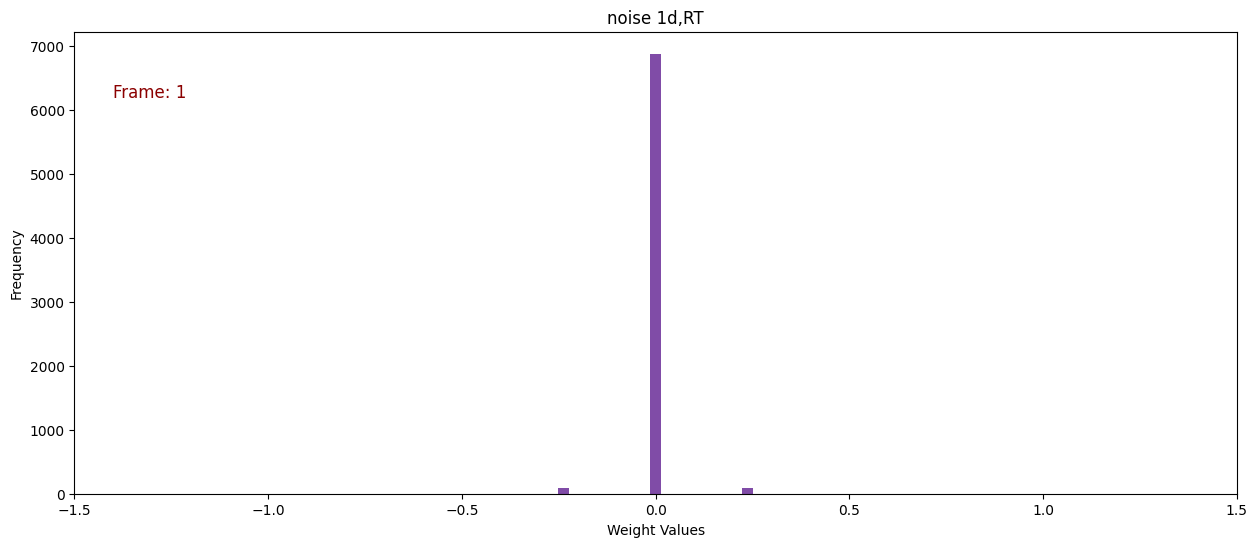

In [8]:
import math

EVAL_NUM =    1 # number of evaluations for a single noise type
RESULTS_DICT =  "resnet9_qhwa_{}_results/evaluation_results".format(level)
os.makedirs(RESULTS_DICT, exist_ok=True)
accuracies = np.zeros((len(types), EVAL_NUM))

# Create the model and prepare it for evaluation
RESNET_MODEL_DICT = "resnet9_qhwa_{}_results_from_scratch/resnet9_quant_{}.th".format(level, level)
state_dict = torch.load(RESNET_MODEL_DICT, map_location=DEVICE)
if hasattr(state_dict, "model_state_dict"):
    loading_state = state_dict["model_state_dict"]
else:
    loading_state = state_dict

# = * = * = * = * = RPU CONFIG PARs = * = * = * = * = * =
gmax = 40.0 # uS maximum conductance mapped value

forward = IOParameters(
inp_res = 254.0,
out_res = 254.0,
# bound_management= BoundManagementType.NONE,
# noise_management= NoiseManagementType.NONE,
w_noise_type= WeightNoiseType.NONE,
)

clip = WeightClipParameter(
    type=WeightClipType.NONE,
)

remap = WeightRemapParameter(
    type=WeightRemapType.NONE,
)

quantizer = WeightQuantizerParameter(
    quantizer_type=WeightQuantizerType.UNIFORM_SYMMETRIC,
    levels = level,
    rel_to_actual_wmax= True,
    resolution = 1./math.log2(float(level) -1.),
    method = "none",
)
# = * = * = * = * = RPU CONFIG PARs = * = * = * = * = * =

for noise in types:
    
    noise_model = ExperimentalNoiseModel(file_path=ex_path, 
                                     type = noise,
                                     levels = level,
                                     force_interpolation=True,
                                     compensation=False,
                                     g_converter = SinglePairConductanceConverter(g_max=gmax))
    
    
    # variables = interpolate(levels=level, type = noise, file_path=ex_path, force_interpolation=True)
    # print("The medians are: ", variables['ww_mdn'].tolist())
    # print("The stds are: ", variables['ww_std'].tolist())
    # shift_std_devs=(variables['ww_std']*1e6).tolist()
    # shift_values=(variables['ww_mdn']*1e6).tolist()

    # modifier = WeightModifierParameter(
    #     type = WeightModifierType.QUANTIZE_ADD_AND_SHIFT,
    #     g_max = gmax,
    #     levels = level,
    #     shift_std_devs=shift_std_devs,
    #     shift_values=shift_values,
        
    # )

    rpu_config = InferenceRPUConfig(
        forward = forward,
        clip = clip,
        remap = remap,
        # modifier = modifier,
        quantization = quantizer,
        drift_compensation = None,
        noise_model = noise_model,
    )


    for rep in range(EVAL_NUM):

        _, validation_data = load_images()
        criterion = nn.CrossEntropyLoss()

        analog_model = create_analog_network(rpu_config, first_layer_quantization = True).to(DEVICE)
        analog_model.load_state_dict(loading_state, load_rpu_config=False)
        analog_model = convert_to_analog(analog_model, rpu_config)
        analog_model.eval()

        # progam the model with the selected noise model
        # analog_model.program_analog_weights()

        # save snapshots of the weights distribution
        if rep == 0:
            pl.generate_moving_hist(analog_model, title = "noise {}".format(noise), file_name = os.path.join(RESULTS_DICT, "weights_{}.gif".format(noise)), range = (-1.5, 1.5), top = None, split_by_rows = False)

        # evaluate the model
        _, _, _, accuracies[types.index(noise), rep] = test_evaluation(validation_data, analog_model, nn.CrossEntropyLoss())

        del analog_model
        torch.cuda.empty_cache()

    print(f"Accuracy for noise {noise} --> mean : {np.mean(accuracies[types.index(noise)])}, std: {np.std(accuracies[types.index(noise)])}")

np.savetxt(os.path.join(RESULTS_DICT, "accuracies.csv"), accuracies, delimiter=",")



    

In [ ]:
accuracies = np.loadtxt(os.path.join(RESULTS_DICT, "accuracies.csv"), delimiter=",")

mean_accuracies = np.mean(accuracies, axis=1)
std_accuracies = np.std(accuracies, axis=1)

# plot the results: x axis is the noise type, y axis is the mean accuracy, error bars are the standard deviation
fig, ax = plt.subplots()
ax.errorbar(types, mean_accuracies, yerr=std_accuracies, fmt='o')
plt.xticks(rotation=45)
plt.ylabel("Accuracy [%]")
plt.title("Accuracy vs noise type")
plt.grid()

In [ ]:
# # Tryout 
# N_EPOCHS = 3
# RESULTS = os.path.join(cur_dir, "tryout".format(level))
# print("Path to store the results: ", RESULTS)
# os.makedirs(RESULTS, exist_ok=True)
# manual_seed(SEED)

# # Load datasets
# train_data, validation_data = load_images()

# # Create RPU configuration
# rpu_config = create_rpu_config(level, add_noise = False)

# print(rpu_config.modifier)

# RESNET_NON_QUANTIZED = "resnet9_qhwa_{}_results_from_scratch/resnet9_quant_{}.th".format(level, level)
# state_dict = torch.load(RESNET_NON_QUANTIZED, map_location=DEVICE)
# if hasattr(state_dict, "model_state_dict"):
#     loading_state = state_dict["model_state_dict"]
# else:
#     loading_state = state_dict

# analog_model_0 = create_analog_network(rpu_config).to(DEVICE)
# analog_model_0.load_state_dict(loading_state)

# analog_model = create_analog_network(rpu_config).to(DEVICE)
# analog_model.load_state_dict(analog_model_0.state_dict(), load_rpu_config=False)


# cuda_check = next(analog_model.parameters()).is_cuda
# print("Model is on cuda: ", cuda_check)

# # pl.generate_moving_hist(analog_model, title = "DISCRETIZED model", file_name = "../this_model.gif", range = (-1.5, 1.5), top = None, split_by_rows = False)

# print(f"\n{datetime.now().time().replace(microsecond=0)} --- " f"Started Resnet9 Example")

# optimizer, scheduler = create_sgd_optimizer(analog_model, LEARNING_RATE * 0.1)
# criterion = nn.CrossEntropyLoss()

# analog_model, optimizer, _ = training_loop(
#     analog_model, criterion, optimizer, scheduler ,train_data, validation_data, N_EPOCHS, RESULTS, "resnet9_quant_{}.th".format(level)
# )

# print(f"{datetime.now().time().replace(microsecond=0)} --- " f"Completed Resnet9 Example")


Path to store the results:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/tryout
Files already downloaded and verified
Files already downloaded and verified



 --------------------------------------------------------------------------------------------------
TYPE: 1d,180°C
MEDIAN VALUES: tensor([-41.9058,   0.1587,  41.7692], dtype=torch.float64)
STD VALUES: tensor([5.1099, 0.0406, 4.6058], dtype=torch.float64)
WeightModifierParameter(res=0.2, type=WeightModifierType.DISCRETIZE)






















































Model is on cuda:  True

12:15:03 --- Started Resnet9 Example
